In [1]:
from functools import partial

import colorcet as cc
import diffrax as dfx
import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax
import scipy.spatial as scspatial
from dynamical_systems.continuous import Lorenz63
from dynamical_systems.dataset import TimeSeriesDataset
from dynamics_discovery.metrics.error import relative_error_norm
from dynamics_discovery.models import (
    LatentLSTM as LatentLSTM,
    LatentRNN as LatentRNN,
    NeuralODE as NeuralODE,
)
from dynamics_discovery.preprocessing import add_noise, standardize
from jaxtyping import Array, Float


jax.config.update("jax_enable_x64", True)
plt.style.use("matplotlib_utils.styles.dash_gridded")

In [2]:
dataset_loaded = TimeSeriesDataset.load("./data/lorenz63.hdf5")[30000:]
noise = 0.0

t_train = dataset_loaded.t[0]
u_orig = dataset_loaded.u[0]
u_orig = add_noise(u_orig, noise)
u_train = standardize(u_orig)
u_std = jnp.std(u_orig, axis=0)

lorenz = Lorenz63()

## Calculate the ground truth one step jacobian of the ODE system


In [3]:
def step(ode, t0, t1, u0):
    sol = dfx.diffeqsolve(
        dfx.ODETerm(ode.rhs),
        dfx.Tsit5(),
        t0,
        t1,
        None,
        u0,
        stepsize_controller=dfx.PIDController(rtol=1e-7, atol=1e-7),
        args=None,
    )
    return sol.ys[0]


@partial(eqx.filter_vmap, in_axes=(None, 0, 0, None))
def jacobian_one_step(ode, t, u, dt):
    @eqx.filter_jacrev
    def _jac_step(t_u):
        t, u = t_u
        return step(ode, t, t + dt, u)

    return _jac_step((t, u))[1]


jac_unscaled = jacobian_one_step(lorenz, t_train, u_orig, t_train[1] - t_train[0])
jac_true = jnp.diag(1 / u_std) @ jac_unscaled @ jnp.diag(u_std)

In [4]:
kdtree = scspatial.KDTree(u_train[:-1])

num_neighbors = 25
_, idx_nn_ = kdtree.query(u_train[:-1], k=num_neighbors + 1)
idx_nn = idx_nn_[:, 1:]

In [5]:
idx_nn.shape

(99999, 25)

In [6]:
@partial(eqx.filter_vmap, in_axes=(None, 0, 0))
def estimate_jacobian(us: Float[Array, "time dim"], idx, idx_nn):
    u0, u1 = us[idx], us[idx + 1]
    u_nn0 = jnp.take(us, idx_nn, axis=0)
    u_nn1 = jnp.take(us, idx_nn + 1, axis=0)

    du0 = u_nn0 - u0
    du1 = u_nn1 - u1
    return (jnp.linalg.pinv(du0) @ du1).T


jac_linregress = estimate_jacobian(u_train, jnp.arange(u_train.shape[0] - 1), idx_nn)


In [7]:
err_linregress = relative_error_norm(jac_linregress, jac_true[:-1], axis=(-2, -1))

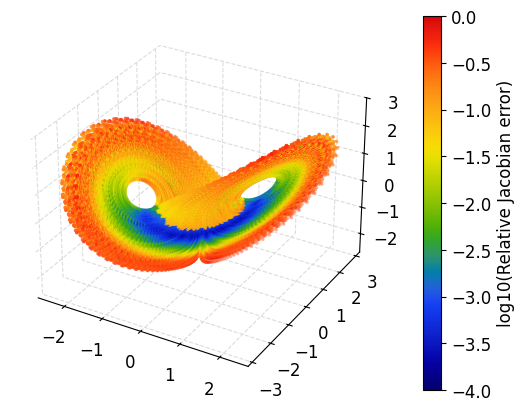

In [8]:
fig, ax = plt.subplots(
    1,
    1,
    figsize=(6, 4),
    subplot_kw={"projection": "3d"},
)
plot = ax.scatter(
    *u_train[:-1].T,
    c=jnp.log10(err_linregress),
    s=3,
    cmap=cc.cm.rainbow4,
    vmin=-4,
    vmax=0.0,
)
fig.colorbar(
    plot,
    ax=ax,
    label=r"log10(Relative Jacobian error)",
)

## Jacobian estimation via neural network

In [25]:
def estimate_step_error(
    model,
    t0: Float[Array, ""],
    u0: Float[Array, " dim"],
    du0: Float[Array, "samples dim"],
    dt: Float[Array, ""],
    second_order: bool = False,
):
    def _step(u):
        return model.step(t0, t0 + dt, u)

    @partial(eqx.filter_vmap, in_axes=(None, 0))
    def step_error(u0: Float[Array, " dim"], u: Float[Array, " dim"]):
        def first_order(u0_):
            if isinstance(model, NeuralODE):
                tu = u - u0_
                return (
                    tu
                    + eqx.filter_jvp(lambda u: model.rhs(t0, u, None), (u0_,), (tu,))[1]
                    * dt
                )
            else:
                return eqx.filter_jvp(_step, (u0_,), (u - u0_,))[1]

        if second_order:
            second_order_term = eqx.filter_jvp(first_order, (u0,), (u - u0,))[1]
            return 1.5 * first_order(u0) + 0.5 * second_order_term
        else:
            return first_order(u0)

    return step_error(u0, u0 + du0)


@partial(eqx.filter_vmap, in_axes=(None, None, None, 0, 0, None, None))
def loss_step_error(model, ts, us, idx, idx_nn, dt, second_order: bool = False):
    t0, u0 = ts[idx], us[idx]
    dt = ts[1] - ts[0]
    du0 = jnp.take(us, idx_nn, axis=0) - u0
    du1 = jnp.take(us, idx_nn + 1, axis=0) - us[idx + 1]
    du1_pred = estimate_step_error(model, t0, u0, du0, dt, second_order)
    return jnp.mean((du1 - du1_pred) ** 2) / jnp.mean((du1) ** 2)


@partial(eqx.filter_vmap, in_axes=(None, None, None, 0, None))
def loss_temporal(model, ts, us, idx: int, train_length: int = 1):
    t_target = jax.lax.dynamic_slice_in_dim(ts, idx, train_length, axis=0)
    u_target = jax.lax.dynamic_slice_in_dim(us, idx, train_length, axis=0)
    u_pred = model.solve(
        t_target, us[idx], None, adjoint=dfx.RecursiveCheckpointAdjoint()
    )
    return jnp.mean((u_pred - u_target) ** 2) / jnp.mean((u_target) ** 2)


@eqx.filter_value_and_grad
def loss_grad_fn(model, t_train, u_train, idx_nn, second_order: bool = False):
    dt = t_train[1] - t_train[0]
    loss_step = jnp.mean(
        loss_step_error(
            model,
            t_train,
            u_train,
            jnp.arange(0, u_train.shape[0] - 1),
            idx_nn,
            dt,
            second_order,
        )
    )
    return loss_step


@eqx.filter_value_and_grad
def hybrid_loss_grad_fn(
    model,
    t_train,
    u_train,
    idx_nn,
    jac_weight: float = 1,
    train_length: int = 1,
    second_order: bool = False,
):
    dt = t_train[1] - t_train[0]
    loss_step = jnp.mean(
        loss_step_error(
            model,
            t_train,
            u_train,
            jnp.arange(0, u_train.shape[0] - 1),
            idx_nn,
            dt,
            second_order,
        )
    )
    loss_time = jnp.mean(
        loss_temporal(
            model,
            t_train,
            u_train,
            jnp.arange(0, u_train.shape[0] - train_length),
            train_length,
        )
    )
    return jac_weight * loss_step + loss_time

In [13]:
model = NeuralODE(3, 32, 3, key=0, solver=dfx.Tsit5())
# model = LatentRNN(3, 60, key=0)
optimizer = optax.adabelief(learning_rate=5e-2)
opt_state = optimizer.init(eqx.filter(model, eqx.is_inexact_array))


@eqx.filter_jit
def step_fn(model, t_train, u_train, idx_nn, opt_state):
    loss, grads = loss_grad_fn(model, t_train, u_train, idx_nn)
    updates, opt_state = optimizer.update(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return loss, model, opt_state


In [14]:
loss_history = []
max_epochs = 2500
for epoch in range(max_epochs):
    loss, model, opt_state = step_fn(model, t_train, u_train, idx_nn, opt_state)
    loss_history.append(loss.item())
    print(f"{epoch=}, {loss=}")
loss_history = jnp.asarray(loss_history)

epoch=0, loss=Array(0.96239579, dtype=float64)
epoch=1, loss=Array(0.96204252, dtype=float64)
epoch=2, loss=Array(0.96007956, dtype=float64)
epoch=3, loss=Array(0.95481152, dtype=float64)
epoch=4, loss=Array(0.94460154, dtype=float64)
epoch=5, loss=Array(0.93501095, dtype=float64)
epoch=6, loss=Array(0.93714924, dtype=float64)
epoch=7, loss=Array(0.92938525, dtype=float64)
epoch=8, loss=Array(0.92813368, dtype=float64)
epoch=9, loss=Array(0.929477, dtype=float64)
epoch=10, loss=Array(0.92878582, dtype=float64)
epoch=11, loss=Array(0.92747864, dtype=float64)
epoch=12, loss=Array(0.92681078, dtype=float64)
epoch=13, loss=Array(0.92623023, dtype=float64)
epoch=14, loss=Array(0.9260736, dtype=float64)
epoch=15, loss=Array(0.92627396, dtype=float64)
epoch=16, loss=Array(0.92577554, dtype=float64)
epoch=17, loss=Array(0.92487688, dtype=float64)
epoch=18, loss=Array(0.92462143, dtype=float64)
epoch=19, loss=Array(0.92464252, dtype=float64)
epoch=20, loss=Array(0.92456906, dtype=float64)
epoch

KeyboardInterrupt: 

Text(0, 0.5, 'Train error')

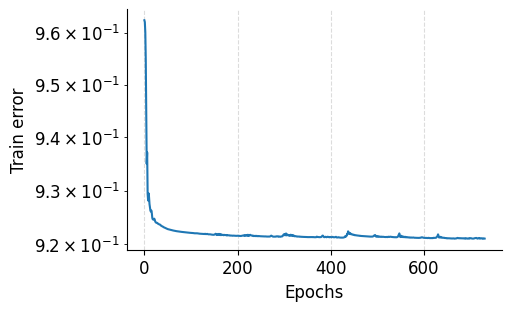

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.plot(loss_history)
ax.set_yscale("log", base=10)
ax.set_xlabel("Epochs")
ax.set_ylabel("Train error")

In [18]:
@partial(eqx.filter_vmap, in_axes=(None, 0, 0, None))
def jacobian_one_step_model(model, t, u, dt):
    @eqx.filter_jacfwd
    def _jac_step(t_u):
        t, u = t_u
        return model.step(t, t + dt, u, adjoint=dfx.ForwardMode(), max_steps=20)

    return _jac_step((t, u))[1]

In [19]:
jac_nn = jacobian_one_step_model(model, t_train, u_train, t_train[1] - t_train[0])
err_nn = relative_error_norm(jac_nn, jac_true, axis=(-2, -1))

In [20]:
model = NeuralODE(3, 32, 3, key=0, solver=dfx.Tsit5())
# model = LatentRNN(3, 60, key=0)
optimizer = optax.adabelief(learning_rate=5e-2)
opt_state = optimizer.init(eqx.filter(model, eqx.is_inexact_array))


@eqx.filter_jit
def step_fn(model, t_train, u_train, idx_nn, opt_state):
    loss, grads = loss_grad_fn(model, t_train, u_train, idx_nn, second_order=True)
    updates, opt_state = optimizer.update(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return loss, model, opt_state


loss_history = []
max_epochs = 10000
for epoch in range(max_epochs):
    loss, model, opt_state = step_fn(model, t_train, u_train, idx_nn, opt_state)
    loss_history.append(loss.item())
    print(f"{epoch=}, {loss=}")
loss_history = jnp.asarray(loss_history)

epoch=0, loss=Array(0.96239578, dtype=float64)
epoch=1, loss=Array(0.96204261, dtype=float64)
epoch=2, loss=Array(0.96007725, dtype=float64)
epoch=3, loss=Array(0.95479408, dtype=float64)
epoch=4, loss=Array(0.94456502, dtype=float64)
epoch=5, loss=Array(0.93500875, dtype=float64)
epoch=6, loss=Array(0.93704161, dtype=float64)
epoch=7, loss=Array(0.92936601, dtype=float64)
epoch=8, loss=Array(0.92802983, dtype=float64)
epoch=9, loss=Array(0.92940949, dtype=float64)
epoch=10, loss=Array(0.92874989, dtype=float64)
epoch=11, loss=Array(0.92744472, dtype=float64)
epoch=12, loss=Array(0.92680813, dtype=float64)
epoch=13, loss=Array(0.92619115, dtype=float64)
epoch=14, loss=Array(0.92604715, dtype=float64)
epoch=15, loss=Array(0.92630546, dtype=float64)
epoch=16, loss=Array(0.92575933, dtype=float64)
epoch=17, loss=Array(0.92486803, dtype=float64)
epoch=18, loss=Array(0.92462527, dtype=float64)
epoch=19, loss=Array(0.92455959, dtype=float64)
epoch=20, loss=Array(0.92446021, dtype=float64)
ep

KeyboardInterrupt: 

Text(0, 0.5, 'Train error')

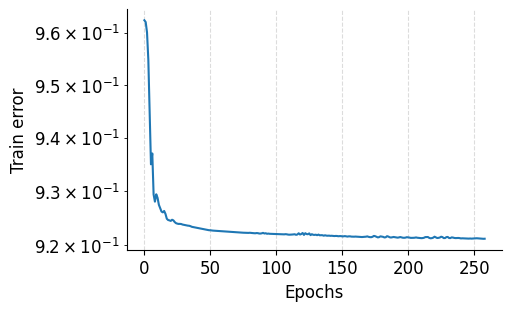

In [21]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.plot(loss_history)
ax.set_yscale("log", base=10)
ax.set_xlabel("Epochs")
ax.set_ylabel("Train error")

In [22]:
jac_nn2 = jacobian_one_step_model(model, t_train, u_train, t_train[1] - t_train[0])
err_nn2 = relative_error_norm(jac_nn2, jac_true, axis=(-2, -1))

In [ ]:
from dynamics_discovery.io import load_model


model_loaded = load_model("results/lorenz63/neuralode/len=2_noise=0.05_key=0.eqx")
object.__setattr__(model_loaded, "solver", dfx.Tsit5(scan_kind="bounded"))
print(model_loaded.solver)
jac_nn_1step = jacobian_one_step_model(
    model_loaded, t_train, u_train, t_train[1] - t_train[0]
)
err_nn_1step = relative_error_norm(jac_nn_1step, jac_true, axis=(-2, -1))

Tsit5(scan_kind='bounded')


Text(0.5, 0.98, 'Relative jacobian error')

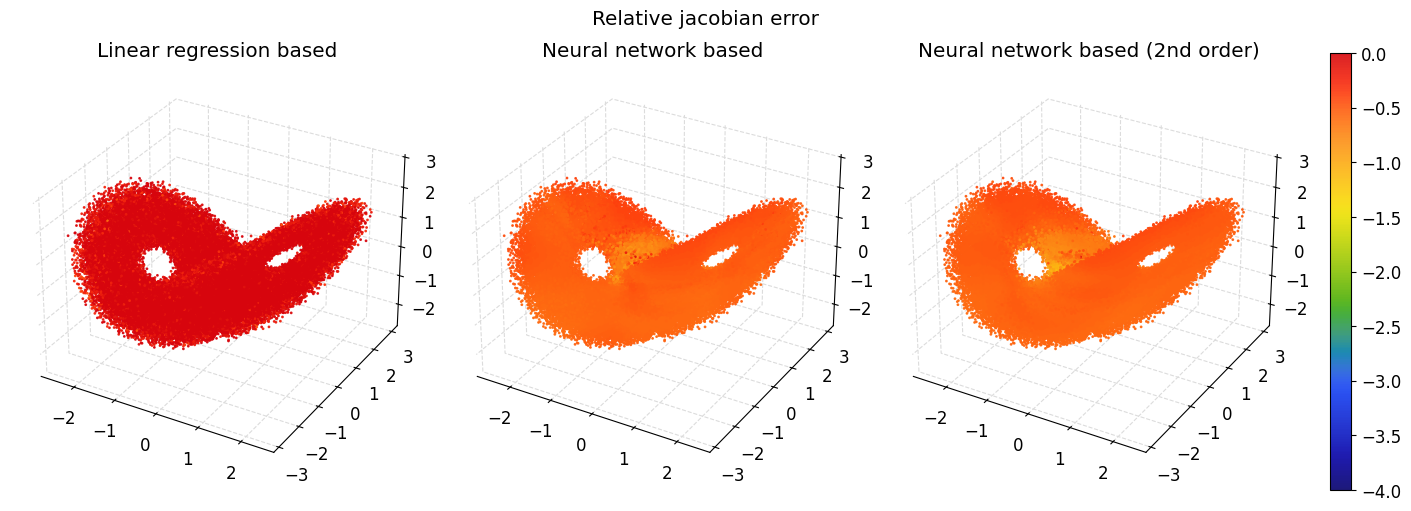

In [23]:
scatter_kwargs = {"s": 1, "cmap": cc.cm.rainbow4, "vmin": -4, "vmax": 0.0, "alpha": 0.9}
fig, axes = plt.subplots(
    1,
    3,
    figsize=(14, 5),
    subplot_kw={"projection": "3d"},
)

axes[0].scatter(*u_train[1:].T, c=jnp.log10(err_linregress), **scatter_kwargs)
axes[1].scatter(*u_train.T, c=jnp.log10(err_nn), **scatter_kwargs)
ax = axes[2].scatter(*u_train.T, c=jnp.log10(err_nn2), **scatter_kwargs)
axes[0].set_title("Linear regression based")
axes[1].set_title("Neural network based")
axes[2].set_title("Neural network based (2nd order)")
fig.colorbar(ax, ax=axes[-1])
fig.suptitle("Relative jacobian error")

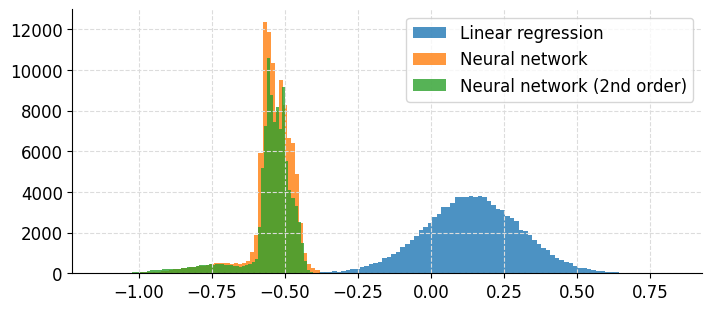

In [24]:
fig, ax = plt.subplots(1, 1, figsize=(7, 3))
hist_kwargs = {"bins": 100, "alpha": 0.8}
ax.hist(jnp.log10(err_linregress), label="Linear regression", **hist_kwargs)
ax.hist(jnp.log10(err_nn), label="Neural network", **hist_kwargs)
ax.hist(jnp.log10(err_nn2), label="Neural network (2nd order)", **hist_kwargs)
ax.legend()

In [38]:
from dynamics_discovery.models import NeuralODE


model = NeuralODE(3, 32, 3, key=0, solver=dfx.Tsit5())
optimizer = optax.adabelief(learning_rate=5e-4)
opt_state = optimizer.init(eqx.filter(model, eqx.is_inexact_array))
train_length = 2
jac_weight = 0.1


@eqx.filter_jit
def hybrid_step_fn(model, t_train, u_train, idx_nn, opt_state):
    loss, grads = hybrid_loss_grad_fn(
        model, t_train, u_train, idx_nn, jac_weight, train_length
    )
    updates, opt_state = optimizer.update(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return loss, model, opt_state


In [39]:
loss_history = []
max_epochs = 2500
for epoch in range(max_epochs):
    loss, model, opt_state = hybrid_step_fn(model, t_train, u_train, idx_nn, opt_state)
    loss_history.append(loss.item())
    print(f"{epoch=}, {loss=}")
loss_history = jnp.asarray(loss_history)

epoch=0, loss=Array(0.11310269, dtype=float64)
epoch=1, loss=Array(0.11309828, dtype=float64)
epoch=2, loss=Array(0.11309365, dtype=float64)
epoch=3, loss=Array(0.1130888, dtype=float64)
epoch=4, loss=Array(0.11308372, dtype=float64)
epoch=5, loss=Array(0.11307842, dtype=float64)
epoch=6, loss=Array(0.11307287, dtype=float64)
epoch=7, loss=Array(0.11306707, dtype=float64)
epoch=8, loss=Array(0.11306102, dtype=float64)
epoch=9, loss=Array(0.1130547, dtype=float64)
epoch=10, loss=Array(0.1130481, dtype=float64)
epoch=11, loss=Array(0.11304121, dtype=float64)
epoch=12, loss=Array(0.11303401, dtype=float64)
epoch=13, loss=Array(0.11302649, dtype=float64)
epoch=14, loss=Array(0.11301861, dtype=float64)
epoch=15, loss=Array(0.11301037, dtype=float64)
epoch=16, loss=Array(0.11300172, dtype=float64)
epoch=17, loss=Array(0.11299264, dtype=float64)
epoch=18, loss=Array(0.11298308, dtype=float64)
epoch=19, loss=Array(0.11297302, dtype=float64)
epoch=20, loss=Array(0.11296239, dtype=float64)
epoch

KeyboardInterrupt: 

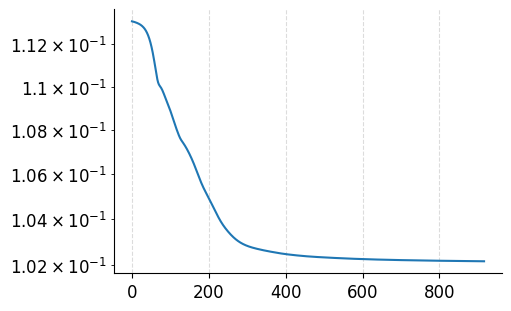

In [40]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.plot(loss_history)
ax.set_yscale("log", base=10)

In [48]:
jac_nn = jacobian_one_step_model(model, t_train, u_train, t_train[1] - t_train[0])
err_nn = relative_error_norm(jac_nn, jac_true, axis=(-2, -1))

Text(0.5, 0.98, 'Relative jacobian error')

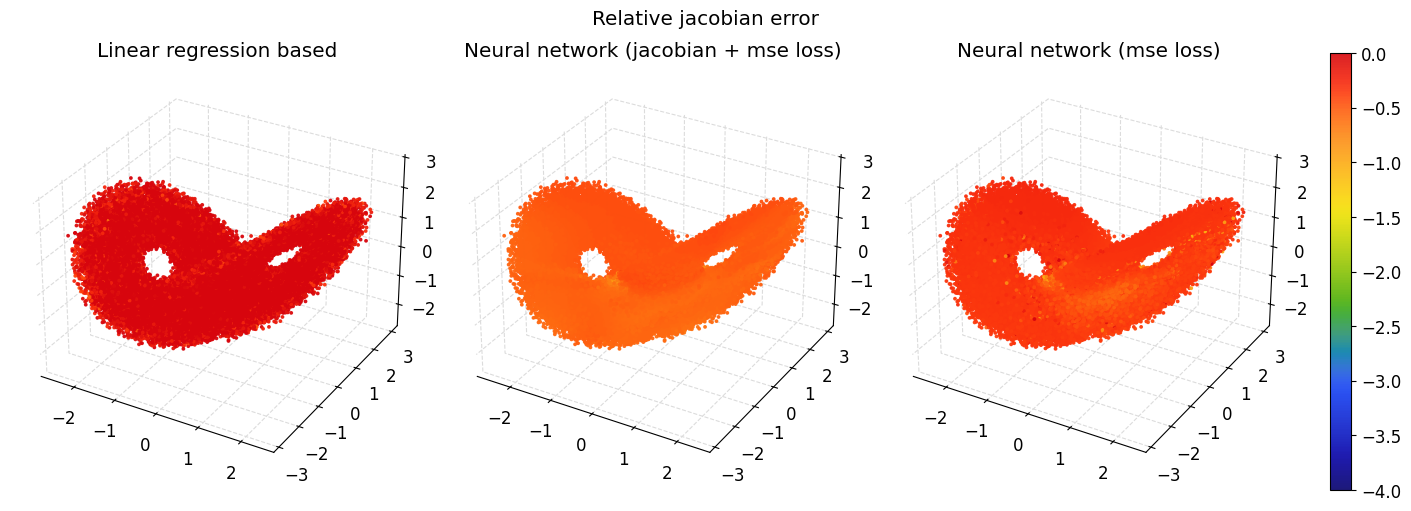

In [49]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(14, 5),
    subplot_kw={"projection": "3d"},
)
scatter_kwargs = {"s": 3, "cmap": cc.cm.rainbow4, "vmin": -4, "vmax": 0.0, "alpha": 0.9}
axes[0].scatter(*u_train[1:].T, c=jnp.log10(err_linregress), **scatter_kwargs)
axes[1].scatter(*u_train.T, c=jnp.log10(err_nn), **scatter_kwargs)
ax = axes[2].scatter(*u_train.T, c=jnp.log10(err_nn_1step), **scatter_kwargs)
axes[0].set_title("Linear regression based")
axes[1].set_title("Neural network (jacobian + mse loss)")
axes[2].set_title("Neural network (mse loss)")
fig.colorbar(ax, ax=axes[-1])
fig.suptitle("Relative jacobian error")

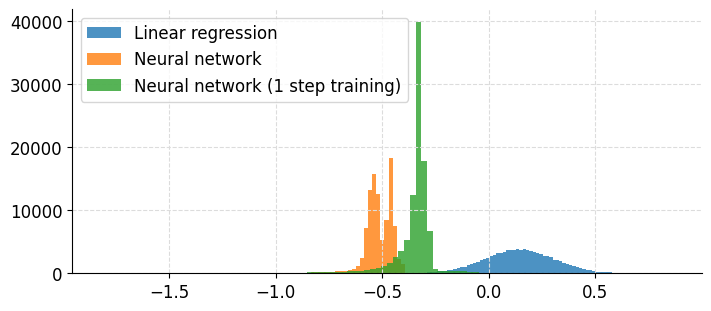

In [50]:
fig, ax = plt.subplots(1, 1, figsize=(7, 3))
ax.hist(jnp.log10(err_linregress), bins=100, label="Linear regression", alpha=0.8)
ax.hist(jnp.log10(err_nn), bins=100, label="Neural network", alpha=0.8)
ax.hist(
    jnp.log10(err_nn_1step),
    bins=100,
    label="Neural network (1 step training)",
    alpha=0.8,
)

ax.legend()

In [51]:
from dynamics_discovery.preprocessing import split_into_chunks


noise = 0

t_train_batch = split_into_chunks(t_train, train_length)
u_train_batch = split_into_chunks(u_train, train_length)
# u_train_batch = add_noise(u_train_batch, noise, key=0)

subsample_factor = u_train_batch.shape[0] // 100
print(t_train_batch.shape)
u_pred_train = eqx.filter_vmap(model.solve)(
    t_train_batch[::subsample_factor], u_train_batch[::subsample_factor, 0]
)
u_pred_test = model.solve(t_train, u_train[0], max_steps=None)


(50000, 2)


Text(0.5, 0.98, 'Latent RNN prediction (train length = 2, seed = 0)')

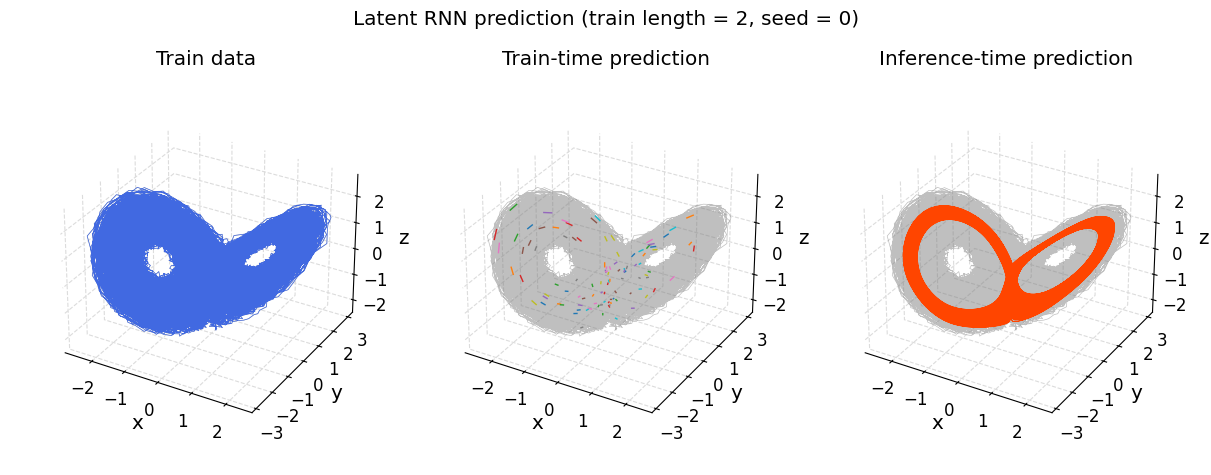

In [52]:
import numpy as np
from matplotlib_utils.axes_setters import set_labels


fig, axes = plt.subplots(
    1,
    3,
    figsize=(12, 5),
    constrained_layout=True,
    subplot_kw={"projection": "3d"},
)
plot_kwargs = {"linewidth": 0.5}
axes[0].set_title("Train data")
axes[0].plot(*u_train.T, color="gray", alpha=0.5, **plot_kwargs)
axes[0].plot(*u_train.T, color="royalblue", **plot_kwargs)

axes[1].plot(*u_train.T, color="gray", alpha=0.5, **plot_kwargs)
for u_i in np.asarray(u_pred_train)[::]:
    axes[1].plot(*u_i.T, linewidth=1.0)
axes[1].set_title("Train-time prediction")
axes[2].plot(*u_train.T, color="gray", alpha=0.5, **plot_kwargs)
axes[2].plot(*u_pred_test.T, color="orangered", **plot_kwargs)
axes[2].set_title("Inference-time prediction")

for ax in axes:
    set_labels(ax, ["x", "y", "z"], fontsize="large")
    ax.set_box_aspect(None, zoom=0.85)
    ax.set_title
fig.suptitle(f"Latent RNN prediction (train length = {train_length}, seed = 0)")


In [22]:
model = LatentRNN(3, 60, key=0)
optimizer = optax.adabelief(learning_rate=5e-4)
opt_state = optimizer.init(eqx.filter(model, eqx.is_inexact_array))


@eqx.filter_jit
def hybrid_step_fn_second_order(model, t_train, u_train, idx_nn, opt_state):
    loss, grads = hybrid_loss_grad_fn_second_order(model, t_train, u_train, idx_nn)
    updates, opt_state = optimizer.update(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return loss, model, opt_state


loss_history = []
max_epochs = 20000
for epoch in range(max_epochs):
    loss, model, opt_state = hybrid_step_fn_second_order(
        model, t_train, u_train, idx_nn, opt_state
    )
    loss_history.append(loss.item())
    print(f"{epoch=}, {loss=}")
loss_history = jnp.asarray(loss_history)

epoch=0, loss=Array(2.06316538, dtype=float64)
epoch=1, loss=Array(1.97772141, dtype=float64)
epoch=2, loss=Array(1.88995574, dtype=float64)
epoch=3, loss=Array(1.80023739, dtype=float64)
epoch=4, loss=Array(1.70896477, dtype=float64)
epoch=5, loss=Array(1.61658311, dtype=float64)
epoch=6, loss=Array(1.52359243, dtype=float64)
epoch=7, loss=Array(1.430538, dtype=float64)
epoch=8, loss=Array(1.33799874, dtype=float64)
epoch=9, loss=Array(1.24657361, dtype=float64)
epoch=10, loss=Array(1.15686519, dtype=float64)
epoch=11, loss=Array(1.06946133, dtype=float64)
epoch=12, loss=Array(0.98491635, dtype=float64)
epoch=13, loss=Array(0.90373347, dtype=float64)
epoch=14, loss=Array(0.82634973, dtype=float64)
epoch=15, loss=Array(0.75312442, dtype=float64)
epoch=16, loss=Array(0.6843315, dtype=float64)
epoch=17, loss=Array(0.62015632, dtype=float64)
epoch=18, loss=Array(0.56069663, dtype=float64)
epoch=19, loss=Array(0.50596774, dtype=float64)
epoch=20, loss=Array(0.45591067, dtype=float64)
epoch

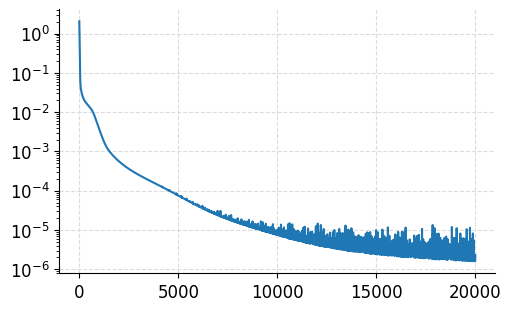

In [23]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.plot(loss_history)
ax.set_yscale("log", base=10)

In [ ]:
jac_nn2 = jacobian_one_step_model(model, t_train, u_train, t_train[1] - t_train[0])
err_nn2 = relative_error(jac_nn2, jac_true, axis=(-2, -1))

Text(0.5, 0.98, 'Relative jacobian error')

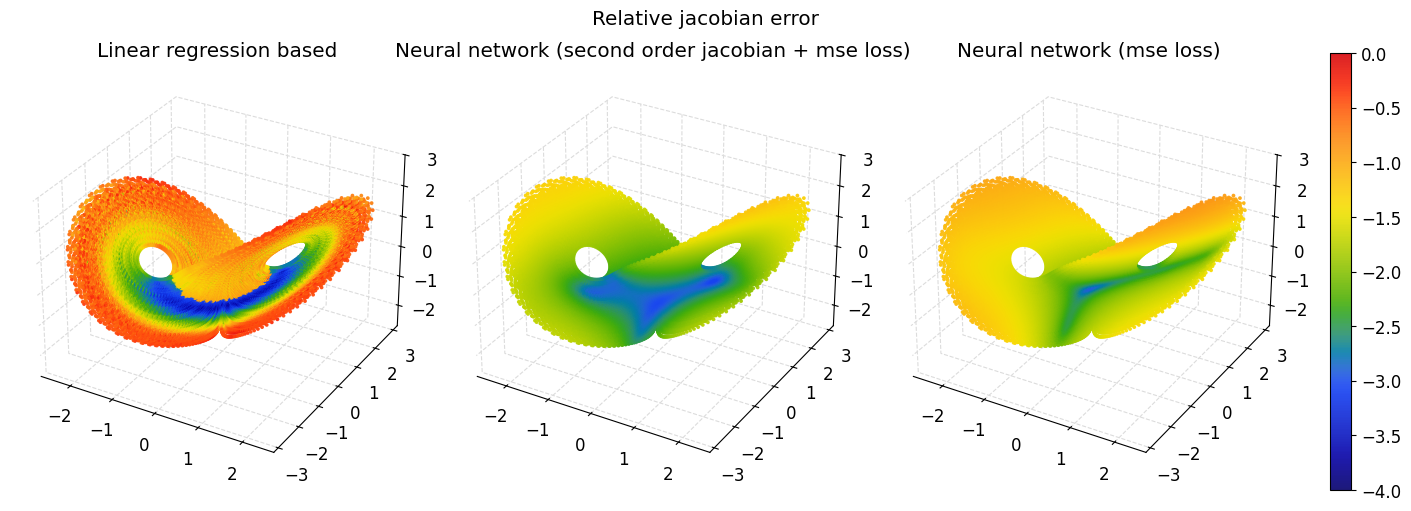

In [25]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(14, 5),
    subplot_kw={"projection": "3d"},
)
scatter_kwargs = {"s": 3, "cmap": cc.cm.rainbow4, "vmin": -4, "vmax": 0.0, "alpha": 0.9}
axes[0].scatter(*u_train[1:].T, c=jnp.log10(err_linregress), **scatter_kwargs)
axes[1].scatter(*u_train.T, c=jnp.log10(err_nn2), **scatter_kwargs)
ax = axes[2].scatter(*u_train.T, c=jnp.log10(err_nn_1step), **scatter_kwargs)
axes[0].set_title("Linear regression based")
axes[1].set_title("Neural network (second order jacobian + mse loss)")
axes[2].set_title("Neural network (mse loss)")
fig.colorbar(ax, ax=axes[-1])
fig.suptitle("Relative jacobian error")

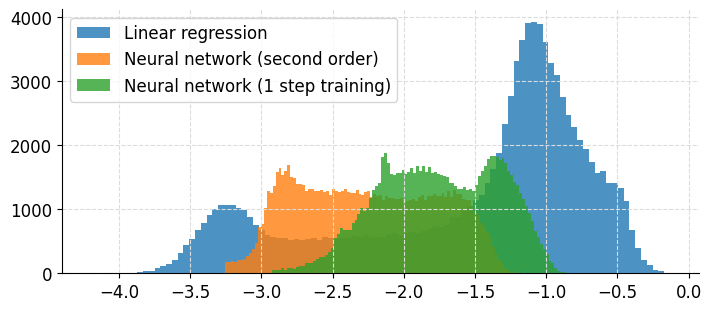

In [26]:
fig, ax = plt.subplots(1, 1, figsize=(7, 3))
ax.hist(jnp.log10(err_linregress), bins=100, label="Linear regression", alpha=0.8)
ax.hist(jnp.log10(err_nn2), bins=100, label="Neural network (second order)", alpha=0.8)
ax.hist(
    jnp.log10(err_nn_1step),
    bins=100,
    label="Neural network (1 step training)",
    alpha=0.8,
)

ax.legend()

(50000, 2)


Text(0.5, 0.98, 'Latent RNN prediction (train length = 2, seed = 0)')

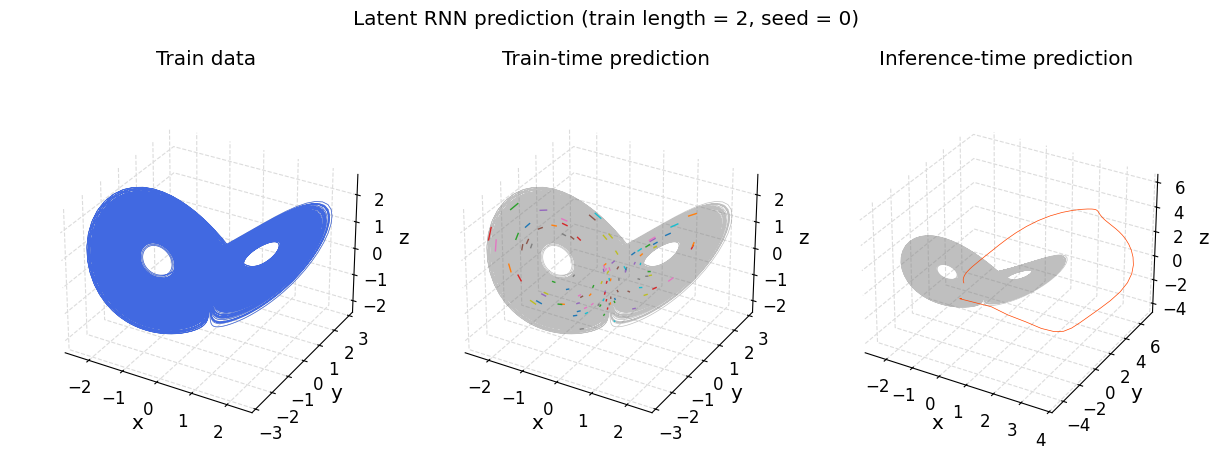

In [27]:
import numpy as np
from dynamics_discovery.preprocessing import split_into_chunks
from matplotlib_utils.axes_setters import set_labels


train_length = 2
noise = 0

t_train_batch = split_into_chunks(t_train, train_length)
u_train_batch = split_into_chunks(u_train, train_length)
# u_train_batch = add_noise(u_train_batch, noise, key=0)

subsample_factor = u_train_batch.shape[0] // 100
print(t_train_batch.shape)
u_pred_train = eqx.filter_vmap(model.solve)(
    t_train_batch[::subsample_factor], u_train_batch[::subsample_factor, 0]
)
u_pred_test = model.solve(t_train, u_train[0], max_steps=None)


fig, axes = plt.subplots(
    1,
    3,
    figsize=(12, 5),
    constrained_layout=True,
    subplot_kw={"projection": "3d"},
)
plot_kwargs = {"linewidth": 0.5}
axes[0].set_title("Train data")
axes[0].plot(*u_train.T, color="gray", alpha=0.5, **plot_kwargs)
axes[0].plot(*u_train.T, color="royalblue", **plot_kwargs)

axes[1].plot(*u_train.T, color="gray", alpha=0.5, **plot_kwargs)
for u_i in np.asarray(u_pred_train)[::]:
    axes[1].plot(*u_i.T, linewidth=1.0)
axes[1].set_title("Train-time prediction")
axes[2].plot(*u_train.T, color="gray", alpha=0.5, **plot_kwargs)
axes[2].plot(*u_pred_test.T, color="orangered", **plot_kwargs)
axes[2].set_title("Inference-time prediction")

for ax in axes:
    set_labels(ax, ["x", "y", "z"], fontsize="large")
    ax.set_box_aspect(None, zoom=0.85)
    ax.set_title
fig.suptitle(f"Latent RNN prediction (train length = {train_length}, seed = 0)")


In [ ]:
neuralode = NeuralODE(3, 32, 3, key=0, solver=dfx.Tsit5(scan_kind="bounded"))
test_ind = 30
t0 = t_train[test_ind]
dt = t_train[1] - t_train[0]

u_test = u_train[test_ind]
tu_test = u_train[idx_nn[test_ind, 0]] - u_train[test_ind]


def neuralode_step_jvp(node: NeuralODE, u, tu, t, dt):
    def _step(u):
        return node.step(t, t + dt, u, adjoint=dfx.DirectAdjoint())

    return eqx.filter_jvp(_step, (u,), (tu,))


def neuralode_step_jvp_approx(node: NeuralODE, u, tu, t, dt):
    def _rhs(u):
        return node.rhs(t, u, None)

    @eqx.filter_custom_jvp
    def _step(u):
        return node.step(t, t + dt, u)

    @_step.def_jvp
    def _step_jvp(primals, tangents):
        (u,) = primals
        (tu,) = tangents
        primal_out = _step(u)
        tangent_out = tu + eqx.filter_jvp(_rhs, (u,), (tu,))[1] * dt
        return primal_out, tangent_out

    return eqx.filter_jvp(_step, (u,), (tu,))


def neuralode_step_jvp_approx(node: NeuralODE, u, tu, t, dt):
    def _rhs(u):
        return node.rhs(t, u, None)

    @eqx.filter_custom_jvp
    def _step(u):
        return node.step(t, t + dt, u)

    @_step.def_jvp
    def _step_jvp(primals, tangents):
        (u,) = primals
        (tu,) = tangents
        primal_out = _step(u)
        tangent_out = tu + eqx.filter_jvp(_rhs, (u,), (tu,))[1] * dt
        return primal_out, tangent_out

    return eqx.filter_jvp(_step, (u,), (tu,))


def neuralode_step_jvp(node: NeuralODE, u, tu, t, dt):
    def _step(u):
        return node.step(t, t + dt, u, adjoint=dfx.DirectAdjoint())

    return eqx.filter_jvp(_step, (u,), (tu,))


neuralode_step_jvp(neuralode, u_test, tu_test, t0, dt)

(Array([-1.38293706, -0.02987855,  1.69067694], dtype=float64),
 Array([-0.02107099, -0.0084502 ,  0.00877096], dtype=float64))

In [40]:
%%timeit
neuralode_step_jvp(neuralode, u_test, tu_test, t0, dt)[1].block_until_ready()

53.5 ms ± 1.22 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [41]:
%%timeit
neuralode_step_jvp_approx(neuralode, u_test, tu_test, t0, dt)[1].block_until_ready()

46.7 ms ± 890 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
